In [1]:
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import List, Dict, Optional
import json, uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from IPython.display import display, Markdown

np.random.seed(33)

root = Path.cwd() / 'agents026'
data_dir = root / 'data'
incidents_dir = data_dir / 'incidents'
audit_dir = data_dir / 'audit'
AUDIT_LOG_PATH = audit_dir / 'audit_log.jsonl'
OPERATOR = 'prasenjit.roychoudhury'

def audit_event(event_type, incident_id, payload):
    rec = {'audit_id': f'aud-{uuid.uuid4().hex[:12]}',
           'timestamp_utc': datetime.now(timezone.utc).isoformat(),
           'event_type': event_type, 'incident_id': incident_id,
           'operator': OPERATOR, 'payload': payload}
    with open(AUDIT_LOG_PATH, 'a', encoding='utf-8') as f:
        f.write(json.dumps(rec, default=str) + '\n')

SERVICE = 'fraud-detection-service'
START = datetime(2026, 6, 11, 16, 0, 0)
N_MIN = 120
print('UC-3 module ready —', SERVICE)

UC-3 module ready — fraud-detection-service


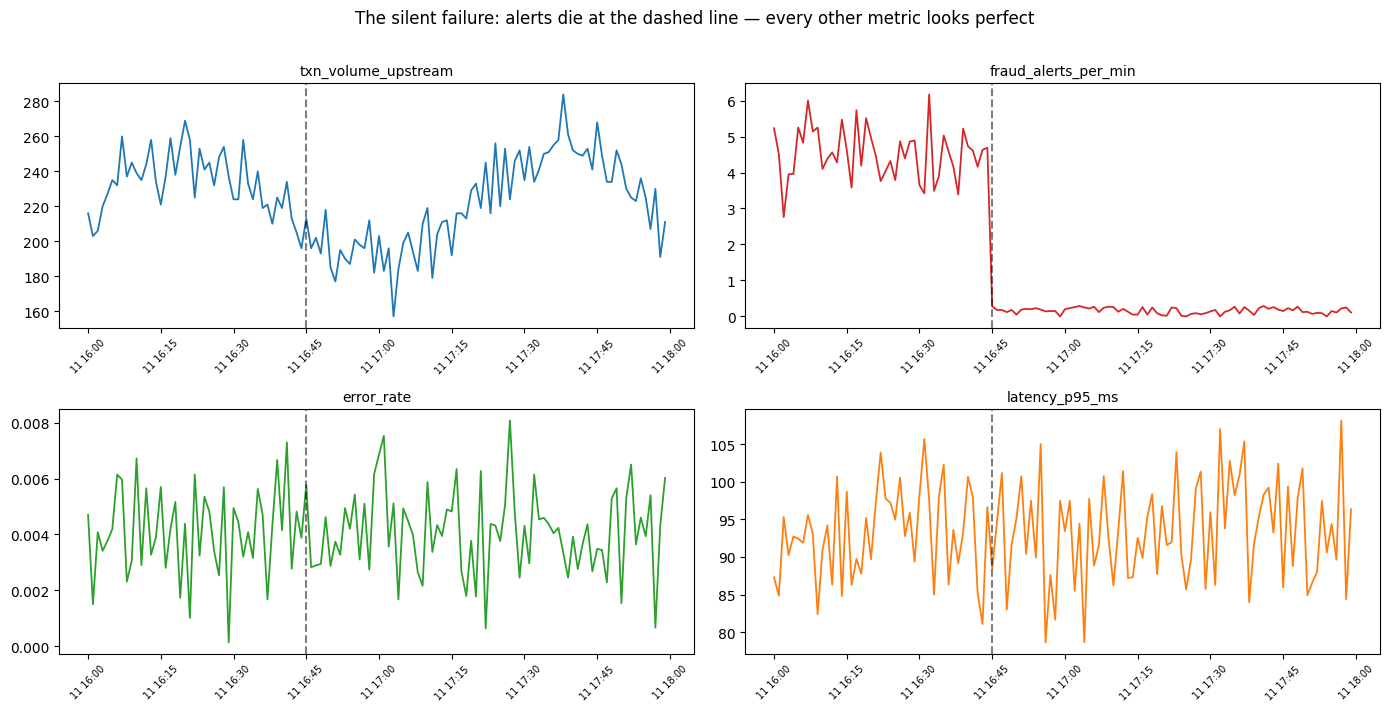

In [2]:
idx = pd.date_range(START, periods=N_MIN, freq='1min')

# Upstream transaction volume — perfectly healthy throughout
txn_volume = (220 + 30 * np.sin(np.linspace(0, 3*np.pi, N_MIN)) + np.random.normal(0, 12, N_MIN)).clip(50, None)

# Fraud alerts emitted: normally ~2% of txns score as alerts… then a bad model deploy at minute 45
alerts = txn_volume * 0.02 + np.random.normal(0, 0.6, N_MIN)
alerts[45:] = np.random.uniform(0, 0.3, N_MIN - 45)   # effectively zero — silent failure

# The trap: ALL standard health metrics stay normal
fraud_df = pd.DataFrame({
    'timestamp': idx,
    'service': SERVICE,
    'txn_volume_upstream': txn_volume.round(0),
    'fraud_alerts_per_min': alerts.clip(0, None).round(2),
    'cpu_utilization': (35 + np.random.normal(0, 4, N_MIN)).clip(0, 100).round(2),
    'latency_p95_ms': (95 + np.random.normal(0, 8, N_MIN)).clip(40, None).round(2),
    'error_rate': np.abs(np.random.normal(0.004, 0.0015, N_MIN)).round(5),
})
fraud_df.to_csv(data_dir / 'fraud_service_metrics.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, m, c in zip(axes.flat,
                    ['txn_volume_upstream', 'fraud_alerts_per_min', 'error_rate', 'latency_p95_ms'],
                    ['tab:blue', 'tab:red', 'tab:green', 'tab:orange']):
    ax.plot(fraud_df.timestamp, fraud_df[m], color=c, lw=1.3)
    ax.axvline(idx[45], color='black', ls='--', alpha=0.5)
    ax.set_title(m, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.suptitle('The silent failure: alerts die at the dashed line — every other metric looks perfect', y=1.01)
plt.tight_layout(); plt.show()

In [3]:
# Apply Phase 3's exact rule set to this service
checks = {
    'cpu > 85': (fraud_df.cpu_utilization > 85).any(),
    'latency > 400ms': (fraud_df.latency_p95_ms > 400).any(),
    'error_rate > 0.05': (fraud_df.error_rate > 0.05).any(),
}
print('Standard threshold rules applied to fraud-detection-service:\n')
for rule, fired in checks.items():
    print(f'  {rule:22s} → {"🔥 FIRED" if fired else "✅ no anomaly"}')

print('\n❌ Result: rule-based detection sees a perfectly healthy service —')
print('   while fraud alerts have been silently dead for', N_MIN - 45, 'minutes.')
print('   In a bank, every undetected minute = unscreened transactions.')

Standard threshold rules applied to fraud-detection-service:

  cpu > 85               → ✅ no anomaly
  latency > 400ms        → ✅ no anomaly
  error_rate > 0.05      → ✅ no anomaly

❌ Result: rule-based detection sees a perfectly healthy service —
   while fraud alerts have been silently dead for 75 minutes.
   In a bank, every undetected minute = unscreened transactions.


In [4]:
def detect_silent_failure(df, signal_col, upstream_col,
                          baseline_window=30, silence_window=10,
                          silence_ratio=0.1, min_upstream_ratio=0.7):
    """
    Flags when `signal_col` drops below `silence_ratio` × its rolling baseline
    for `silence_window` consecutive minutes WHILE `upstream_col` remains healthy
    (>= min_upstream_ratio × its baseline). Upstream check avoids false positives
    when traffic genuinely stopped.
    """
    out = df.copy()
    out['signal_baseline'] = out[signal_col].rolling(baseline_window, min_periods=10).mean().shift(1)
    out['upstream_baseline'] = out[upstream_col].rolling(baseline_window, min_periods=10).mean().shift(1)

    silent = (out[signal_col] < silence_ratio * out['signal_baseline']) & \
             (out[upstream_col] >= min_upstream_ratio * out['upstream_baseline'])

    out['silent_flag'] = silent.rolling(silence_window).sum() >= silence_window
    return out

det = detect_silent_failure(fraud_df, 'fraud_alerts_per_min', 'txn_volume_upstream')
first_detection = det[det.silent_flag].timestamp.min()
detection_minute = det[det.silent_flag].index.min()

print(f'🚨 SILENT FAILURE DETECTED at minute {detection_minute} ({first_detection})')
print(f'   Failure began at minute 45 → detection lag: {detection_minute - 45} minutes')
print(f'   Alerts at detection: {det.loc[detection_minute, "fraud_alerts_per_min"]:.1f}/min '
      f'(baseline was {det.loc[detection_minute, "signal_baseline"]:.1f}/min)')
print(f'   Upstream txn volume: {det.loc[detection_minute, "txn_volume_upstream"]:.0f}/min — healthy, so this is NOT a traffic drop')

🚨 SILENT FAILURE DETECTED at minute 54 (2026-06-11 16:54:00)
   Failure began at minute 45 → detection lag: 9 minutes
   Alerts at detection: 0.2/min (baseline was 3.2/min)
   Upstream txn volume: 187/min — healthy, so this is NOT a traffic drop


In [5]:
class IncidentCandidate(BaseModel):
    incident_id: str
    start_time: datetime
    end_time: datetime
    services: List[str]
    anomaly_type: str
    metric_summary: Dict[str, float] = Field(default_factory=dict)
    log_samples: List[str] = Field(default_factory=list)
    k8s_event_samples: List[str] = Field(default_factory=list)
    change_refs: List[str] = Field(default_factory=list)

s_time = pd.Timestamp(idx[45])
uc3_incident = IncidentCandidate(
    incident_id='inc-016',
    start_time=s_time.to_pydatetime(),
    end_time=pd.Timestamp(first_detection).to_pydatetime(),
    services=[SERVICE],
    anomaly_type='silent_failure_signal_absence',
    metric_summary={
        'fraud_alerts_baseline_per_min': float(det.signal_baseline.iloc[44]),
        'fraud_alerts_current_per_min': float(det.loc[detection_minute, 'fraud_alerts_per_min']),
        'txn_volume_upstream': float(det.loc[detection_minute, 'txn_volume_upstream']),
        'detection_lag_minutes': float(detection_minute - 45),
        'error_rate_max': float(fraud_df.error_rate.max()),  # normal! that's the point
    },
    log_samples=[
        f"{idx[44].isoformat()} [INFO] fraud-detection-service: scored batch, 4 alerts emitted",
        f"{idx[50].isoformat()} [INFO] fraud-detection-service: scored batch, 0 alerts emitted",
        f"{idx[60].isoformat()} [INFO] fraud-detection-service: scored batch, 0 alerts emitted",
        "NOTE: no ERROR logs — service reports healthy while producing nothing",
    ],
    change_refs=[f"{idx[43].isoformat()} [deploy] fraud-model v7.2 deployed to fraud-detection-service (new scoring threshold config)"],
)

# Append to incident store (idempotent)
inc_path = incidents_dir / 'incident_candidates.json'
existing = [x for x in json.load(open(inc_path, encoding='utf-8')) if x['incident_id'] != 'inc-016']
existing.append(uc3_incident.model_dump())
json.dump(existing, open(inc_path, 'w', encoding='utf-8'), default=str, indent=2)

# CRITICAL-CONTROL POLICY: fraud systems get NO auto-remediation, period.
CRITICAL_CONTROL_SERVICES = ['fraud-detection-service']

escalation = {
    'escalation_id': f'esc-{uuid.uuid4().hex[:8]}',
    'incident_id': 'inc-016',
    'severity': 'CRITICAL',
    'reason': 'Silent failure of a regulatory fraud control. Policy prohibits autonomous remediation '
              'of critical-control services; mandatory human escalation.',
    'auto_remediation_blocked': True,
    'proposed_actions_for_human': [
        {'action_type': 'rollback_deploy', 'target': SERVICE, 'parameters': {'version': 'fraud-model v7.1'},
         'requires_approval': True, 'status': 'awaiting_human'},
        {'action_type': 'restart_service', 'target': SERVICE,
         'requires_approval': True, 'status': 'awaiting_human'},
    ],
    'notified': ['on-call SRE', 'fraud-ops team', 'compliance officer'],
}

audit_event('critical_silent_failure_detected', 'inc-016', {
    'service': SERVICE, 'detection_lag_min': int(detection_minute - 45),
    'unscreened_minutes': int(detection_minute - 45),
    'method': 'absence_of_signal_detector'})
audit_event('mandatory_human_escalation', 'inc-016', escalation)

display(Markdown(f'''
### 🚨 inc-016 — CRITICAL silent failure escalated
| | |
|---|---|
| Detection method | **absence-of-signal** (threshold rules saw nothing) |
| Detection lag | {detection_minute - 45} minutes after failure began |
| Policy applied | **critical-control service → auto-remediation BLOCKED** |
| Proposed to human | rollback to fraud-model v7.1, restart — both awaiting approval |
| Notified | on-call SRE · fraud-ops · compliance |
| Audit | detection + escalation logged |

**Even restart_service — auto-approved elsewhere — requires a human here.** Policy is service-aware, not just action-aware.
'''))

json.dump(escalation, open(incidents_dir / 'inc-016_escalation.json', 'w', encoding='utf-8'), default=str, indent=2)
print('Escalation persisted. The pending actions can now be approved in your HITL console (Phase 8 or Streamlit).')


### 🚨 inc-016 — CRITICAL silent failure escalated
| | |
|---|---|
| Detection method | **absence-of-signal** (threshold rules saw nothing) |
| Detection lag | 9 minutes after failure began |
| Policy applied | **critical-control service → auto-remediation BLOCKED** |
| Proposed to human | rollback to fraud-model v7.1, restart — both awaiting approval |
| Notified | on-call SRE · fraud-ops · compliance |
| Audit | detection + escalation logged |

**Even restart_service — auto-approved elsewhere — requires a human here.** Policy is service-aware, not just action-aware.


Escalation persisted. The pending actions can now be approved in your HITL console (Phase 8 or Streamlit).


In [6]:
import os
from pydantic_ai import Agent
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider

class RCAResult(BaseModel):
    incident_id: str
    root_cause_hypothesis: str
    impacted_components: List[str]
    probable_trigger: Optional[str] = None
    evidence: List[str] = Field(default_factory=list)
    confidence: float = Field(..., ge=0.0, le=1.0)

provider = OpenAIProvider(base_url='http://localhost:8000/v1', api_key='abc-123')
chat_model = OpenAIChatModel('Qwen3-30B-A3B', provider=provider)

rca_agent = Agent(model=chat_model, output_type=RCAResult,
    system_prompt='''You are an SRE root-cause-analysis agent for a banking platform.
Be evidence-based. Return structured RCAResult only. Use only the supplied context.
Note: this is a SILENT failure — the service emits no errors; the signal is absence of expected output.''')

ctx = {'incident': uc3_incident.model_dump(),
       'detection_note': 'fraud_alerts_per_min collapsed to ~0 while upstream txn volume stayed healthy; no error logs; deploy of fraud-model v7.2 occurred 2 minutes before collapse'}
result = await rca_agent.run('Analyze this silent-failure incident and return RCAResult:\n' + json.dumps(ctx, default=str))
rca16 = result.output
print(rca16.model_dump_json(indent=2))

rca_path = incidents_dir / 'rca_results.json'
rca_all = [x for x in json.load(open(rca_path, encoding='utf-8')) if x['incident_id'] != 'inc-016']
rca_all.append(rca16.model_dump())
json.dump(rca_all, open(rca_path, 'w', encoding='utf-8'), default=str, indent=2)
print('\nrca_results.json now has', len(rca_all), 'results')

{
  "incident_id": "inc-016",
  "root_cause_hypothesis": "The silent failure in the fraud-detection-service is likely due to the recent deployment of fraud-model v7.2, which introduced a new scoring threshold configuration. This change caused the service to incorrectly filter out legitimate fraud alerts, resulting in a significant drop in alerts to near zero.",
  "impacted_components": [
    "fraud-detection-service",
    "fraud-model v7.2"
  ],
  "probable_trigger": "Deployment of fraud-model v7.2 with new scoring threshold configuration",
  "evidence": [
    "Fraud alerts per minute dropped from 4.487 to 0.23",
    "No error logs were generated, indicating the service was reported as healthy",
    "The deployment of fraud-model v7.2 occurred 2 minutes before the alert collapse",
    "Log samples show 0 alerts emitted after the deployment"
  ],
  "confidence": 0.95
}

rca_results.json now has 5 results
